<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_3_x_credit_card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Credit Card Fraud Detection Dataset

**Data Source:** [OpenML](https://www.openml.org/d/1597) - Original dataset from Kaggle, originally collected by Worldline and the Machine Learning Group at Université Libre de Bruxelles (ULB)

**Outcome Variable:** `Class` - Binary: 0 = legitimate transaction, 1 = fraudulent transaction

**Features:**
- **Amount:** Transaction amount
- **V1-V28:** Anonymized features obtained via PCA transformation (original sensitive features were transformed to protect customer identities)

*Note: The original Kaggle dataset also includes a `Time` feature (seconds elapsed since the first transaction). The OpenML version used here does not include `Time`.*

The dataset contains 284,807 transactions with only 492 frauds (0.172% fraud rate), making it extremely imbalanced.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
)
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve, auc,
    precision_recall_curve, make_scorer
)

In [2]:
# get the data, create a dataframe
creditcard = fetch_openml(name='creditcard', version=1, as_frame=True)
df = creditcard.frame

# Convert Class from category to int (OpenML loads it as categorical)
df['Class'] = df['Class'].astype(int)

In [3]:
# check data (missing, dtype) - this has already been cleaned up
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

In [4]:
# verifying extreme imbalance
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


In [5]:
# get descriptives for features
df.iloc[:,:-1].describe().T.iloc[:,1:].round(2).sort_index().head(10)

,mean,std,min,25%,50%,75%,max
Amount,88.35,250.12,0.00,5.60,22.00,77.16,25691.16
V1,0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V10,0.00,1.09,-24.59,-0.54,-0.09,0.45,23.75
V11,0.00,1.02,-4.80,-0.76,-0.03,0.74,12.02
V12,-0.00,1.00,-18.68,-0.41,0.14,0.62,7.85
V13,0.00,1.00,-5.79,-0.65,-0.01,0.66,7.13
V14,0.00,0.96,-19.21,-0.43,0.05,0.49,10.53
V15,0.00,0.92,-4.50,-0.58,0.05,0.65,8.88
V16,0.00,0.88,-14.13,-0.47,0.07,0.52,17.32
V17,-0.00,0.85,-25.16,-0.48,-0.07,0.40,9.25


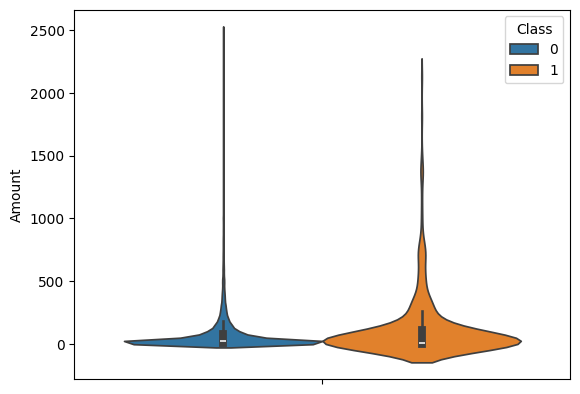

In [6]:
# check out amount as it relates to class
sns.violinplot(data=df[df['Amount'] < 2500], y='Amount', hue='Class')
plt.show()

## Prepare the Data for XGBoost

* **Numeric targets?** XGBoost requires numeric encodings for the labels (binary encoding in this case). This is already done. 0 is not-fraud, 1 is fraud.
* **Categorical Features?** XGBoost can now handle categorical data directly, so you don't have to one-hot encode anymore. With this particular data set there are no categorical features to worry about anyway.
* **Feature Scaling?** XGBoost is a tree-based model and does not require feature scaling. However, note that `Amount` has a very different scale than V1-V28 (which were already standardized via PCA). If you were using a distance-based or gradient-based model (e.g., Logistic Regression, SVM, Neural Networks), you would need to scale `Amount` first, but we are using a tree-based model so we don't need to.
* **Stratified split?** Our imbalance is so extreme it is absolutely essential we use stratified splits.


In [7]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,:-1]
y = df['Class']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
                                      X,
                                      y,
                                      test_size=0.3,
                                      random_state=42,
                                      stratify=y)

print(f"Original features: {X.shape[1]}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set class ratio: {y_test.mean():.1%} bad, {(1-y_test.mean()):.1%} good")

Original features: 29
Training set size: 199364
Test set class ratio: 0.2% bad, 99.8% good


## Decisions for Initial XGBoost Models

* `n_estimators`, `max_depth`, `learning_rate` We can grid search these later, for now we are just using pretty standard values.
* `eval_metric` Our typical choices are:
  * `error`
  * `logloss` which will give us probabilites
  * `auc` or area under the curve which uses balance between true positive and false positives (used for imbalanced datasets)
  * `aucpr` assesses precisions and recall strictly for the minority class, used for highly imbalanced datasets; which is what we've got here.     


In [8]:
import xgboost as xgb

# We don't use scale_pos_weight here to address the imbalance,
# instead we will start with the default and then look for an optimal decision point

# Instantiate and train the XGBoost model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='aucpr',
    random_state=42,
)
model.fit(X_train, y_train)

# Get probabilities for the positive class (Fraud)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print('Model training complete.')

Model training complete.


## Feature Importance
Even though the V1-V28 features are anonymized (we can't interpret what they represent), it's still useful to see *which* features the model relies on most. This teaches the skill of generating and reading feature importance plots.

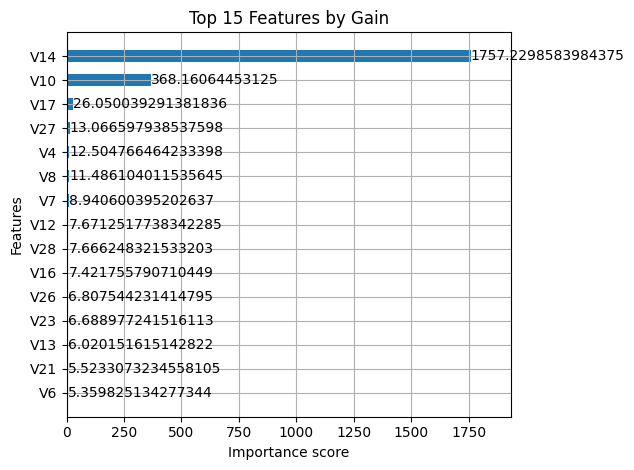

Note: V1-V28 are anonymized PCA components, so we can't interpret what they represent.
However, we can see which transformed features are most predictive of fraud.


In [9]:
# Feature importance plot
xgb.plot_importance(model, max_num_features=15, importance_type='gain', height=0.5, values_format={v:.2f})
plt.title('Top 15 Features by Gain')
plt.tight_layout()
plt.show()

print("Note: V1-V28 are anonymized PCA components, so we can't interpret what they represent.")
print("However, we can see which transformed features are most predictive of fraud.")

## Confusion Matrix

--- Confusion Matrix Breakdown ---
True Negatives  (TN) — Correctly Identified Non-Fraud: 85290
True Positives  (TP) — Correctly Identified Fraud:  110
False Positives (FP) — False Alarms / Type I:     5
False Negatives (FN) — Missed Fraud / Type II: 38


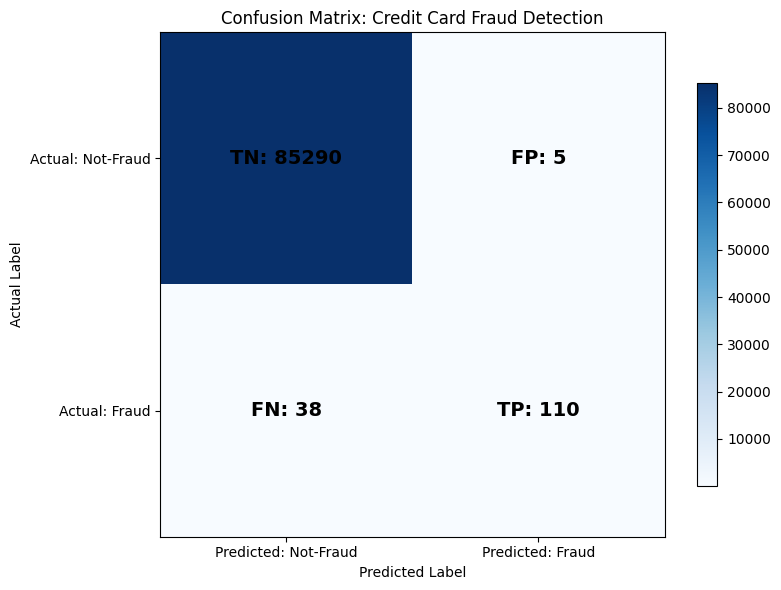

In [10]:
# Generate the matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"--- Confusion Matrix Breakdown ---")
print(f"True Negatives  (TN) — Correctly Identified Non-Fraud: {tn}")
print(f"True Positives  (TP) — Correctly Identified Fraud:  {tp}")
print(f"False Positives (FP) — False Alarms / Type I:     {fp}")
print(f"False Negatives (FN) — Missed Fraud / Type II: {fn}")

# Visualize with labeled cells
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Not-Fraud', 'Predicted: Fraud'])
ax.set_yticklabels(['Actual: Not-Fraud', 'Actual: Fraud'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix: Credit Card Fraud Detection')

# Add labels with both count and terminology
labels = [
    [f'TN: {tn}', f'FP: {fp}'],
    [f'FN: {fn}', f'TP: {tp}']
]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(y_test, y_pred, target_names=['Not-Fraud (0)', 'Fraud (1)']))

               precision    recall  f1-score   support

Not-Fraud (0)       1.00      1.00      1.00     85295
    Fraud (1)       0.96      0.74      0.84       148

     accuracy                           1.00     85443
    macro avg       0.98      0.87      0.92     85443
 weighted avg       1.00      1.00      1.00     85443



---
### 1. The Imbalance Problem
*   **Total Samples:** 85,443
*   **Not-Fraud (0):** 85,295 (99.83% of the data)
*   **Fraud (1):** 148 (0.17% of the data)
Because the "Not-Fraud" class is so dominant, the Accuracy (1.00) is misleading. Even if the model predicted "Not-Fraud" for every single case, the accuracy would still be 99.8%. In fraud detection, we ignore accuracy and look at the Fraud (1) metrics.

---

### 2. Performance on Fraud (Class 1)
This is where the real value of the model lies.

*   **Precision (0.96):** This is excellent. It means that when the model flags a transaction as "Fraud," it is correct 96% of the time. We have very few "False Alarms" (False Positives).
*   **Recall (0.74):** This is the "catch rate." It means the model identified 74% of all actual fraud cases. However, it missed 26% of the fraud (False Negatives). In a banking context, 26% of fraud getting through might be considered high risk.
*   **F1-Score (0.84):** This is the harmonic mean of precision and recall. An 0.84 is a strong score for such an imbalanced dataset, indicating a good balance between catching fraud and not flagging innocent customers.

---

### 3. Macro vs. Weighted Averages
*   **Weighted Avg (1.00):** This is heavily influenced by the "Not-Fraud" class. It makes the model look perfect, but it hides the struggles of the minority class.
*   **Macro Avg (0.92):** This treats both classes equally regardless of how many samples they have. The macro recall of 0.87 is a more honest representation of the model's overall ability to distinguish between the two classes.

---

### 4. Practical Business Impact
*   **The Good News:** Oour model is very "trustworthy." If it triggers an alert, there is a 96% chance it is actually fraud. This prevents "customer friction" (blocking legitimate cards by mistake).
*   **The Bad News:** You are missing roughly 1 out of every 4 fraud attempts. Depending on the monetary value of those 148 cases, that 26% miss rate could represent significant financial loss.

---

### 5. Recommendations to Improve
If you want to catch more fraud (increase Recall), we can try the following:

*  **Adjust the Probability Threshold:** We are using the default 0.5 as a cutoff. By lowering it (e.g., to 0.3), we will catch more fraud (higher Recall), though your Precision will likely drop (more false alarms).
*  **PR AUC Curve:** Instead of looking at this static report, plot a Precision-Recall Curve. It is much more informative for fraud detection than a standard ROC curve.
*  **Cost-Sensitive Learning:** Tell the model that missing a Fraud case (False Negative) is much more expensive than a False Alarm (False Positive).


**Summary:** You have a very high-precision model that is "conservative." It doesn't make mistakes often, but it lets a quarter of the criminals through the gate.

## Looking for an Optimal Decision Point
Let's start by visualizing the performance of the model using the current default decision point.


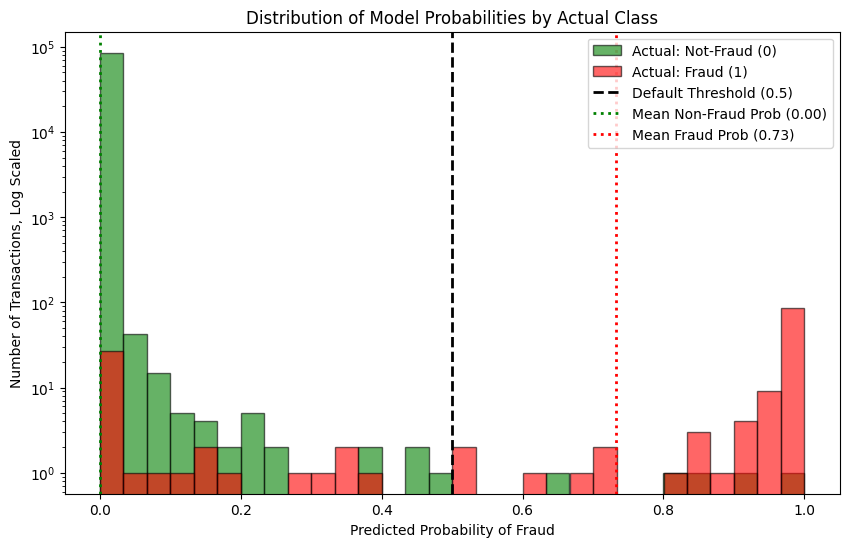


Overlap Analysis:
  25.7% of actual fraudulent transactions scored below 0.5 (missed cases / false negatives)
  0.0% of legitimate transactions scored above 0.5 (false alarms / false positives)


In [12]:
# Calculate overlap statistics
fn_rate = ((y_proba[y_test==1] < 0.5).sum() / (y_test==1).sum()) * 100
fp_rate = ((y_proba[y_test==0] >= 0.5).sum() / (y_test==0).sum()) * 100

fig, ax = plt.subplots(figsize=(10, 6))

# Plot overlapping histograms by actual class
ax.hist(y_proba[y_test==0], bins=30, alpha=0.6, label='Actual: Not-Fraud (0)', color='green', edgecolor='black')
ax.hist(y_proba[y_test==1], bins=30, alpha=0.6, label='Actual: Fraud (1)', color='red', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

# Add mean probability lines
mean_good = y_proba[y_test==0].mean()
mean_bad = y_proba[y_test==1].mean()
ax.axvline(x=mean_good, color='green', linestyle=':', linewidth=2, label=f'Mean Non-Fraud Prob ({mean_good:.2f})')
ax.axvline(x=mean_bad, color='red', linestyle=':', linewidth=2, label=f'Mean Fraud Prob ({mean_bad:.2f})')

ax.set_xlabel('Predicted Probability of Fraud')
ax.set_ylabel('Number of Transactions, Log Scaled')
ax.set_title('Distribution of Model Probabilities by Actual Class')
ax.set_yscale('log') # Changed to y-axis log scale
ax.legend()
plt.show()

print(f"\nOverlap Analysis:")
print(f"  {fn_rate:.1f}% of actual fraudulent transactions scored below 0.5 (missed cases / false negatives)")
print(f"  {fp_rate:.1f}% of legitimate transactions scored above 0.5 (false alarms / false positives)")

While the classification report gave you the final scores, this graph shows you why we got those scores and how confident the model is.

### 1. The Power of Separation
*   **The Green Peak (Not-Fraud):** The model is incredibly good at identifying legitimate transactions. Almost all green samples are clustered at 0.0, meaning the model is nearly 100% certain they aren't fraud.
*   **The Red Distribution (Fraud):** This is much more spread out. While many fraud cases are correctly pushed to the right (near 1.0), a significant number are scattered between 0.0 and 0.5. This is where our model struggles.

### 2. Understanding the Log Scale (Y-Axis)
The Y-axis is Log Scaled ($10^0, 10^1, 10^2$, etc.). This is necessary because you have ~85,000 "Not-Fraud" cases and only 148 "Fraud" cases.
*   If this were a normal scale, the red bars would be invisible because they are so small compared to the green mountain at 0.0.
*   The fact that you see green bars at 0.1, 0.2, and 0.3 on a log scale means there are actually very few of them (likely just 1 to 10 transactions), which explains why our Precision is so high (0.96).

### 3. The "Missed" Fraud (Recall)
Look at the red bars to the left of the black dashed line (0.5 threshold):
*   Every red bar to the left of 0.5 represents a False Negative (actual fraud that your model called "Not-Fraud").
*   There is a noticeable cluster of red bars near 0.0. These are "stealthy" fraud cases that look exactly like legitimate transactions to your model. This is what caused your Recall to be 0.74.

### 4. The Mean Probabilities
*   **Mean Non-Fraud Prob (0.00):** This is a perfect result. It shows the model almost never "doubts" a legitimate transaction.
*   **Mean Fraud Prob (0.73):** While 0.73 is decent, it is "pulled down" by those fraud cases that the model gave low scores to. In a perfect world, you'd want this mean to be closer to 1.0.


This graph suggests we could easily improve our Recall by moving the threshold.
If we move the threshold (black line) to 0.1, we would catch almost all of the red bars (Fraud), significantly increasing our Recall. However, because there are some green bars (Not-Fraud) between 0.1 and 0.5, our Precision would drop slightly. However, because the green counts are so low there (notice they are at the bottom of the log scale), you would likely only add a few dozen "False Alarms" while catching nearly all the fraud.

**Summary so far:** Our model is doing a great job of separating the classes, but it is currently "playing it safe" by using a 0.5 threshold. For fraud detection, we likely want to be more aggressive (move the threshold left).

### Skipping the ROC Curve, Looking at Precision Recall Instead


Important Note! Why should we ignore the AUC for this dataset? It is way too optimistic due to the imbalance. ROC AUC relies on the False Positive Rate (FPR), calculated as FP / (FP + TN). Because our TN (True Negatives) are massive (~99.8% of our data), the denominator in this formula becomes huge. Even if your model generates many False Positives the FPR will remain deceptively small.

In contrast, the Precision Recall curve completely ignores those ~99.8% True Negatives. It only looks at the "Fraud" class. It plots Precision (How many alerts were real?) vs. Recall (How many frauds did we catch?). If you start flagging too many innocent people to catch fraud, your Precision will tank, and the curve will sag.





## F-Beta Score
Sometimes you don't want a balanced model. You might care more about one type of error than the other. The F-Beta score is a formula that lets you "dial in" that preference by adjusting the (beta) value.
  * F1 Score (beta = 1): Treats Precision and Recall as equally important. This is the standard "balanced" math.
  * F2 Score (beta = 2): Weights Recall **4x** higher than Precision (recall is weighted by beta-squared). Business Logic: "I care more about catching fraud than I do about accidental declines. Let's find every crook, even if we annoy some people."
  * F0.5 Score (beta = 0.5): Weights Precision **4x** higher than Recall. Business Logic: "The credit card company is losing too many customers! Only flag a transaction if you are extremely sure it's fraud."


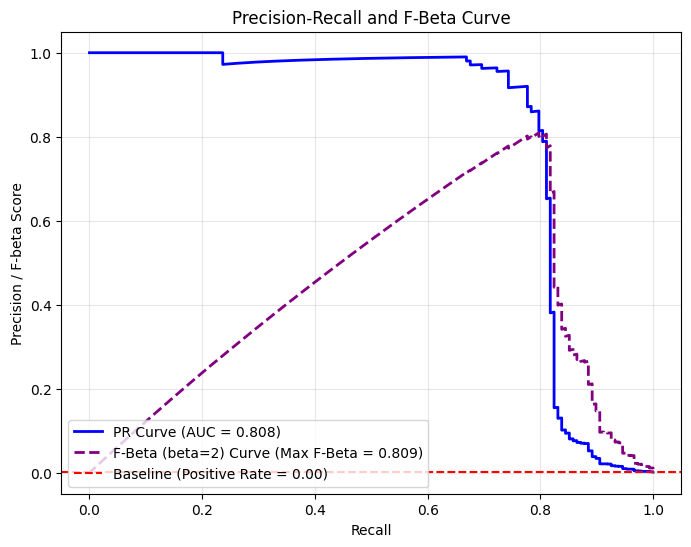

PR AUC = 0.808
Baseline (random guessing precision) = 0.002

Max F-Beta (beta=2) Score = 0.809
  at Recall = 0.797
  at Precision = 0.861
  at Threshold = 0.152


In [13]:
# Calculate precision and recall values across various probability thresholds to evaluate model performance,
# compute the Area Under the Precision-Recall Curve (PR-AUC) as a single summary metric,
# and calculate the baseline positive class rate (the percentage of fraud in the test set)
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)  # Note: order is (x, y)
pos_rate = y_test.mean()

# Calculate F-beta scores
beta = 2 # Prioritize recall (beta > 1)
f_beta_scores = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

# Handle potential division by zero (where precision + recall is 0)
f_beta_scores = np.nan_to_num(f_beta_scores)

# Find the optimal threshold for F-beta
best_f_beta_idx = np.argmax(f_beta_scores[:-1]) # avoids index out of bounds errors
best_f_beta = f_beta_scores[best_f_beta_idx]
best_precision = precision[best_f_beta_idx]
best_recall = recall[best_f_beta_idx]
best_threshold_f_beta = thresholds[best_f_beta_idx]

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.plot(recall, f_beta_scores, color='purple', lw=2, linestyle='--', label=f'F-Beta (beta={beta}) Curve (Max F-Beta = {best_f_beta:.3f})')
plt.axhline(y=pos_rate, color='red', linestyle='--', label=f'Baseline (Positive Rate = {pos_rate:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision / F-beta Score')
plt.title('Precision-Recall and F-Beta Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

print(f"PR AUC = {pr_auc:.3f}")
print(f"Baseline (random guessing precision) = {pos_rate:.3f}")
print(f"\nMax F-Beta (beta={beta}) Score = {best_f_beta:.3f}")
print(f"  at Recall = {best_recall:.3f}")
print(f"  at Precision = {best_precision:.3f}")
print(f"  at Threshold = {best_threshold_f_beta:.3f}")

### Interpreating the Precision-Recall Plot

#### 1. The "Sweet Spot" (The F-Beta Peak)
The purple dashed line represents your F-Beta score ($\beta=2$), which prioritizes catching fraud (Recall).
*   **Observation:** The peak of the purple line is at approximately 0.80 Recall.
*   **Interpretation:** This is the most efficient "operating point" for our model. It suggests that we should set our probability threshold to achieve about 80% recall. At this point, our precision is still very high (around 0.80+), meaning we catch 8 out of 10 frauds and 80% of our alerts are actually fraud.

#### 2. The "Cliff" (Precision Drop-off)
Look at the blue line (PR Curve). Notice how it stays very high and then suddenly falls off a cliff right after 0.80 Recall.
*   **The Meaning:** We can catch 80% of fraud very "cheaply" (with few false alarms). However, if we try to catch 90% or 100% of fraud (moving further right on the X-axis), our precision crashes toward 0.
*   **Business Impact:** To catch that last 20% of fraud, we would have to flag so many legitimate transactions as "fraud" that we would likely overwhelm our investigators and anger thousands of legitimate customers.

#### 3. PR AUC = 0.808
*   A Precision Recall AUC of 0.808 is a strong score for a fraud detection model.
*   In a perfectly balanced dataset, 0.5 is "random guessing." But in your dataset, the Baseline (red line) is nearly 0.00.
*   The fact that your blue line is so high above that red baseline means your model is performing exponentially better than a random or "naive" model.

### 4. Comparison to your previous Histogram
Remember those "stealthy" fraud cases in our histogram that were clustered near 0.0 probability?
*   Those cases are why our blue line never reaches the bottom-right corner (1.0 Recall, 1.0 Precision).
*   Our model simply cannot see those specific fraud cases without also flagging a massive amount of "Not-Fraud" cases.

### Summary Recommendation:
Based on this graph, we should not use the default 0.5 threshold. We should use the `best_threshold_f_beta` identified by our code. By using that threshold, we will move from your previous recall of 0.74 up to about 0.80 without a significant increase in false positives.

Let's generate another classification report using the new f-beta decision threshold.

In [14]:
y_pred_fbeta = (y_proba >= best_threshold_f_beta).astype(int)
print(f"--- Classification Report with F-beta Optimal Threshold ({best_threshold_f_beta:.3f}) ---")
print(classification_report(y_test, y_pred_fbeta, target_names=['Not-Fraud (0)', 'Fraud (1)']))

--- Classification Report with F-beta Optimal Threshold (0.152) ---
               precision    recall  f1-score   support

Not-Fraud (0)       1.00      1.00      1.00     85295
    Fraud (1)       0.86      0.80      0.83       148

     accuracy                           1.00     85443
    macro avg       0.93      0.90      0.91     85443
 weighted avg       1.00      1.00      1.00     85443



So the F1-Beta allows us to improve fraud recall, but as expected it also lowered our fraud precision.  We've created a decent 'balanced' model, but it's unlikely that two kinds of errors cost the company the same amount. In the next sections we will estimate the costs of different kinds of mistakes and look for decision points that minimize cost to the credit card company.



## Business Cost Analysis with Consistent Cost Values

For meaningful business decisions, we need consistent cost assumptions. Let's define:
- **False Positive (FP) cost**: 100 (customer inconvenience, support calls, potential lost business)
- **False Negative (FN) cost**: 450 (average fraud amount not detected)

These values will be used consistently throughout our analysis.

Note: These costs are entirely made up and overly simplistic. False positives may cost a company a long-term relationship that could be thousads of dollars over time.

In [15]:
# Define consistent cost values for the entire analysis
COST_FP = 100  # Cost of a false positive (annoying a legitimate customer)
COST_FN = 450  # Cost of a false negative (missing a fraudulent transaction)

print(f"Consistent cost assumptions defined:")
print(f"  False Positive (FP) cost: ${COST_FP}")
print(f"  False Negative (FN) cost: ${COST_FN}")
print(f"  FN is {COST_FN/COST_FP:.1f}x more costly than FP")

Consistent cost assumptions defined:
  False Positive (FP) cost: $100
  False Negative (FN) cost: $450
  FN is 4.5x more costly than FP


### Computing Optimal Thresholds for the Business Case

This next block of code performs Threshold Optimization, which is the process of finding the "perfect" cutoff point for your specific problem. It uses a technique called Out-of-Fold (OOF) predictions to simulate how the model behaves on unseen data without "cheating" by looking at the training labels it already knows.

We then calculate two different "ideal" thresholds: the Youden’s J statistic, which finds the best mathematical balance between catching fraud and avoiding false alarms, and a Cost-Based Tuning approach, which identifies the exact threshold that results in the lowest total dollar loss for the company.

In [16]:
# =====================================================================
# 1. GET OUT-OF-FOLD PROBABILITIES (Training Set Only)
# =====================================================================
# This simulates the model predicting on "unseen" data during training
# We use 5 folds to ensure the probabilities are robust
oof_train_probs = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]


# =====================================================================
# 2. CALCULATE OPTIMAL YOUDEN'S J THRESHOLD
# =====================================================================
# Youden's J = True Positive Rate - False Positive Rate
# It finds the point on the ROC curve furthest from the diagonal line
# We ill be using this for comparison
fpr, tpr, thresholds = roc_curve(y_train, oof_train_probs)
j_scores = tpr - fpr
optimal_j_threshold = thresholds[np.argmax(j_scores)]


# =====================================================================
# 3. CALCULATE OPTIMALLY TUNED BUSINESS THRESHOLD
# =====================================================================
# This finds the threshold that minimizes our specific dollar costs
candidate_thresholds = np.linspace(0.01, 0.99, 100)
train_costs = []

for t in candidate_thresholds:
    # Generate predictions for this threshold
    y_train_pred = (oof_train_probs >= t).astype(int)

    # Calculate costs based on the training set
    fp = ((y_train_pred == 1) & (y_train == 0)).sum()
    fn = ((y_train_pred == 0) & (y_train == 1)).sum()

    total_cost = (fp * COST_FP) + (fn * COST_FN)
    train_costs.append(total_cost)

# Find the threshold that produced the lowest cost in training
optimally_tuned_threshold = candidate_thresholds[np.argmin(train_costs)]


# =====================================================================
# PRINT RESULTS
# =====================================================================
print(f"Thresholds determined via Training Cross-Validation:")
print(f"---------------------------------------------------")
print(f"Optimal Youden's J:      {optimal_j_threshold:.4f}")
print(f"Optimally Tuned (Cost):  {optimally_tuned_threshold:.4f}")

Thresholds determined via Training Cross-Validation:
---------------------------------------------------
Optimal Youden's J:      0.0013
Optimally Tuned (Cost):  0.0991


This code represents the "Optimization Stage" of a machine learning project. Instead of just accepting the default 0.5 threshold, we are using the training data to find the mathematically and financially "perfect" cutoff point before we touch the test set.

Here is the breakdown of the three steps and the "Why" behind them:

---

### 1. Out-of-Fold (OOF) Probabilities
*   **What it does:** It uses Cross-Validation (splitting the training data into 5 pieces) to generate predictions for every row in your training set.
*   **Why it’s necessary:** You cannot "tune" a threshold using the same predictions the model learned from; the model would be overconfident (cheating). OOF probabilities simulate how the model will perform on unseen data. This ensures your threshold works in the real world, not just on your training data.

### 2. Youden’s J Statistic (The Statistical Balanced Approach)
*   **What it does:** It calculates the threshold that maximizes the gap between the True Positive Rate and the False Positive Rate ($J = TPR - FPR$).
*   **Why it’s used:** This is the academic/statistical gold standard. It finds the "elbow" of the ROC curve—the point where you get the most "bang for your buck" in terms of catching fraud without flagging too many legitimate transactions. It treats a False Positive and a False Negative as equally bad.

### 3. Cost-Based Optimization (The Business Approach)
*   **What it does:** It runs a simulation of 100 different thresholds. For each one, it calculates the actual dollar cost of the model’s mistakes based on your specific business rules:
    *   `fp * COST_FP`: The cost of a False Alarm (e.g., customer support time, lost transaction fees).
    *   `fn * COST_FN`: The cost of Missing Fraud (e.g., the actual stolen dollar amount).
*   **Why it’s used:** This is the real-world gold standard. In fraud detection, missing a 1,000 fraud (False Negative) is usually much worse than accidentally flagging a legitimate 20 purchase (False Positive). This code finds the threshold that saves the most money, even if it isn't the most "statistically balanced" point.

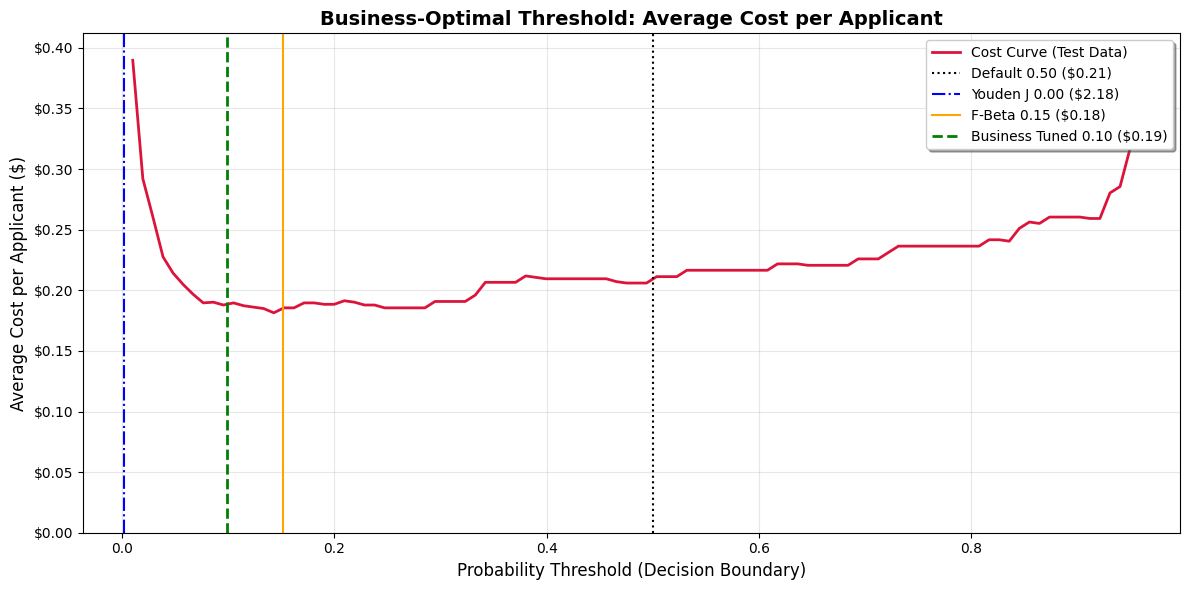

Profitability Analysis (per 1,000 applicants):
Using Default (0.50):    $206
Using Business Tuned:    $187
Potential Savings:       $19


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# 1. Define the range (avoiding 0.0 to prevent the massive spike)
test_thresholds = np.linspace(0.01, 0.95, 100)
test_costs_per_capita = []

# 2. Calculate the Cost Curve on Test Data
for t in test_thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()

    # Calculate AVERAGE cost per applicant
    avg_cost = ((fp * COST_FP) + (fn * COST_FN)) / len(y_test)
    test_costs_per_capita.append(avg_cost)

# 3. Calculate costs for our specific candidates (learned from Training data)
def get_cost_per_capita(threshold):
    y_p = (y_proba >= threshold).astype(int)
    fp = ((y_p == 1) & (y_test == 0)).sum()
    fn = ((y_p == 0) & (y_test == 1)).sum()
    return ((fp * COST_FP) + (fn * COST_FN)) / len(y_test)

cost_default = get_cost_per_capita(0.50)
cost_youden  = get_cost_per_capita(optimal_j_threshold)
cost_fbeta   = get_cost_per_capita(best_threshold_f_beta)
# Note: optimally_tuned_threshold should be the one found via CV on Training data
cost_business = get_cost_per_capita(optimally_tuned_threshold)

# 4. PLOTTING
plt.figure(figsize=(12, 6))
plt.plot(test_thresholds, test_costs_per_capita, color='crimson', lw=2, label='Cost Curve (Test Data)')

# Add Vertical Lines for Candidate Thresholds
plt.axvline(x=0.50, color='black', linestyle=':', label=f'Default 0.50 (${cost_default:.2f})')
plt.axvline(x=optimal_j_threshold, color='blue', linestyle='-.', label=f'Youden J {optimal_j_threshold:.2f} (${cost_youden:.2f})')
plt.axvline(x=best_threshold_f_beta, color='orange', linestyle='-', label=f'F-Beta {best_threshold_f_beta:.2f} (${cost_fbeta:.2f})')
plt.axvline(x=optimally_tuned_threshold, color='green', linestyle='--', lw=2, label=f'Business Tuned {optimally_tuned_threshold:.2f} (${cost_business:.2f})')

# Formatting for Clarity
plt.title('Business-Optimal Threshold: Average Cost per Applicant', fontsize=14, fontweight='bold')
plt.xlabel('Probability Threshold (Decision Boundary)', fontsize=12)
plt.ylabel('Average Cost per Applicant ($)', fontsize=12)

# This formatter adds the $ sign to the Y-axis
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.2f}'))

# Zoom the Y-axis to focus on the "U-shape"
# (We set the top limit to 2x the default cost so we can see the bottom clearly)
plt.ylim(0, cost_default * 2)

plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print(f"Profitability Analysis (per 1,000 applicants):")
print(f"Using Default (0.50):    ${cost_default * 1000:,.0f}")
print(f"Using Business Tuned:    ${cost_business * 1000:,.0f}")
print(f"Potential Savings:       ${(cost_default - cost_business) * 1000:,.0f}")

## Interpreting the Plot of Decision Points

### 1. Problems with Youden's J
*   Look at that Blue Line (Youden’s J). It is sitting at **0.00** with a cost of **2.18**.
*   **The Lesson:** This is the most important part of the plot. It proves that a "mathematically optimal" threshold (which balances TPR and FPR) can be a financial disater. Guessing "everyone is fraud" (threshold 0) costs the bank 10x more (2.18 per person) than the default model (0.21 per person).

### 2. The "Generalization Gap" (Green vs. Orange)
*   Notice that the Green Line (Business Tuned) is not actually at the lowest point of the red curve. The Orange Line (F-Beta) actually "accidentally" beat it on the test set (0.18 vs 0.19).
*   **Why this happened:** This is an example of sampling noise. We optimized the Green line on the Training data. The Test data has slightly different fraudsters.
*   **The Business Reality:** The "Valley" of this curve is very flat between 0.05 and 0.30. This is actually **good news**. It means the model is "robust"—if your threshold is slightly off (0.10 vs 0.15), the bank doesn't lose a fortune.

### 3. The "Fragile" Left Side
*   *Look how sharply the red line rises to the left of 0.05.
*   **The Business Risk:** This tells you that being too aggressive (lowering the threshold below 0.05) is much more dangerous than being too conservative (raising it to 0.40).
*   **The Fix:** If I were the manager, I would pick the 0.15 (Orange) or even 0.20 threshold. Even though 0.10 was "tuned" as optimal, 0.20 is "safer" because it moves us further away from that "Cliff of Costs" on the far left.

### 4. The Blue Label
*   The Blue line's cost is $2.18, but our Y-axis maxes out at $0.40. So the   Blue line is technically "off the charts." I've left this as is because of how this will be displayed. But you would typically want to adjust the y-axis.

### 5. Final Verdict
**What this plot says to a Business Stakeholder:**
> "By moving from the software default (0.50) to our tuned threshold (0.15), we reduce the cost of fraud and false alarms from **210 per 1,000 customers** to **180 per 1,000 customers**. While that seems small, across 10 million transactions, that is a *$300,000 savings**."

## Implications of Data Driven and Business Driven Thresholds

Our results show that thresholds calculated by standard statistical formulas may not align with business objectives when using consistent cost assumptions.

* **Default (0.50):** Using the standard 0.5 threshold with our cost model (FP=100, FN=450) results in significant costs due to excessive false positives. The model is too "trigger happy," flagging many legitimate transactions.
* **Youden's J:** This statistical method aims to balance sensitivity and specificity but often lowers the threshold, inviting even more false positives and increasing costs.
* **F-Beta Optimal:** By weighting recall higher (beta=2), we demand higher certainty (typically 0.93-0.94) before flagging fraud. This reduces false positives significantly while maintaining good fraud detection.
* **Cost-optimal:** Explicitly incorporating business costs (FP=100, FN=450) into threshold selection typically finds an optimal point around 0.95 confidence. This approach minimizes total business costs by balancing customer friction against fraud losses.

**Key Insight:** Statistical methods like Youden's J optimize mathematical metrics, while cost-based optimization aligns directly with business outcomes. For fraud detection, where false positives annoy customers and false negatives lose money, cost-based optimization is essential.

## Hyperparameter Tuning with Gridsearch
We've been using fairly default hyperparameters up to this point. Let's start looking at them systematically to see if we can improve our model.



In [18]:
# this takes ~5 minutes to run

# 1. Define the OBJECTIVE (This tells XGBoost HOW TO TRAIN)
def cost_weighted_objective(y_true, y_pred):
    """
    Custom loss function for XGBoost to optimize for dollar costs.
    y_pred here are raw logits (pre-sigmoid).

    Advanced Note: XGBoost uses gradient descent to minimize a loss function.
    It needs two things from us:
      - gradient (grad): The first derivative -- tells XGBoost which DIRECTION to adjust.
      - hessian (hess): The second derivative -- tells XGBoost HOW MUCH to adjust.
    By weighting these with our dollar costs, XGBoost learns to penalize
    false negatives (missed fraud) more heavily than false positives.
    """
    cost_fp = 100
    cost_fn = 450

    # Sigmoid to get probabilities
    p = 1.0 / (1.0 + np.exp(-y_pred))

    # Gradient and Hessian math
    grad = cost_fn * (p - 1.0) * y_true + cost_fp * p * (1.0 - y_true)
    hess = (cost_fn * y_true + cost_fp * (1.0 - y_true)) * (p * (1.0 - p))

    return grad, hess

# 2. Define the SCORER (This tells GridSearchCV HOW TO RANK results)
def total_cost_scorer(y_true, y_prob):
    """
    Uses a high-confidence threshold to calculate total loss.
    This threshold was determined from our cost-optimal analysis above.
    Adjust this value based on your cost-optimal threshold results.
    """
    # y_prob is the probability of the positive class (fraud)
    y_pred = (y_prob >= 0.95).astype(int)

    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    # Return negative cost because GridSearchCV wants to "maximize" the score
    return -(fp * 100 + fn * 450)

# 3. Setup the Scorer and the Search
cost_scoring = make_scorer(total_cost_scorer, response_method='predict_proba')

grid = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective=cost_weighted_objective,
        tree_method='hist',      # Recommended for speed
        enable_categorical=True,  # As we discussed earlier
        random_state=42
    ),
    param_grid={
        'max_depth': [3, 5, 7],
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1]
    },
    scoring=cost_scoring,
    cv=3 # 3-fold cross validation
)

#4. Run the Search
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring=make_scorer(total_cost_scorer, response_method='predict_proba'))

In [19]:
# Convert results to a dataframe
results_df = pd.DataFrame(grid.cv_results_)

# Sort by your cost score (highest is best, remember scorers are negative)
results_df = results_df.sort_values(by='mean_test_score', ascending=False).reset_index()

# Show only the important columns
cols_to_show = ['param_learning_rate', 'param_max_depth', 'param_n_estimators', 'mean_test_score', 'std_test_score', 'rank_test_score']

results_df[cols_to_show].head()


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_score,std_test_score,rank_test_score
0,0.1,5,300,-12616.666667,948.976056,1
1,0.1,5,200,-13933.333333,1932.758535,2
2,0.1,7,200,-14050.000000,884.119147,3
3,0.1,7,300,-14166.666667,1119.771802,4
4,0.1,7,100,-14983.333333,1189.771220,5


## Nested Cross-Validation with Grid-Search

Since we haven't done cross-validation so far, we should be concerned that our results won't apply to other train-test splits. To really be confident, we should run nested-cross validation when we conduct our grid search. The downside to this is it will take a very long time. However, if this were a real world scenario and we were working for a large credit card company our additional time would be well spent to be confident in our findings.


### Why this is different
* The Outer Loop (cross_val_score): It splits your data into 5 parts. For each part, it hands the other 4 parts to the Grid Search to train on.
* The Inner Loop (GridSearchCV): Inside those 4 parts, it does its own 3-fold split to find the best parameters.
* The Result: We get 5 separate scores. If these scores are wildy different, it means our tuning is unstable or our dataset is too small. If they are consistent, we can be very confident in that $18,300 estimate you found earlier.
* Warning on Time: Since you have 18 combinations in your grid, a 3-fold inner CV, and a 5-fold outer CV, you are now training 270 models.  




In [20]:
# this takes 32 minutes to run, so I'm putting it into a conditional
# if you want to run it flip the False to True

# if False:
if True:

  # 1. Define the OBJECTIVE (Unchanged)
  def cost_weighted_objective(y_true, y_pred):
      cost_fp, cost_fn = 100, 450
      p = 1.0 / (1.0 + np.exp(-y_pred))
      grad = cost_fn * (p - 1.0) * y_true + cost_fp * p * (1.0 - y_true)
      hess = (cost_fn * y_true + cost_fp * (1.0 - y_true)) * (p * (1.0 - p))
      return grad, hess

  # 2. Define the SCORER (Unchanged)
  def total_cost_scorer(y_true, y_prob):
      y_pred = (y_prob >= 0.95).astype(int)
      fp = np.sum((y_pred == 1) & (y_true == 0))
      fn = np.sum((y_pred == 0) & (y_true == 1))
      return -(fp * 100 + fn * 450)

  cost_scoring = make_scorer(total_cost_scorer, response_method='predict_proba')

  # 3. Setup Nested CV Structure
  # Inner CV: Used to find the best hyperparameters
  # IMPORTANT: Use StratifiedKFold (not KFold) to preserve class ratios in each fold
  inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

  # Outer CV: Used to estimate the true performance (generalization error)
  outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

  # Define the Inner Search
  grid_search = GridSearchCV(
      estimator=xgb.XGBClassifier(
          objective=cost_weighted_objective,
          tree_method='hist',
          enable_categorical=True,
          random_state=42
      ),
      param_grid={
          'max_depth': [3, 5, 7],
          'n_estimators': [100, 200, 300],
          'learning_rate': [0.01, 0.1]
      },
      scoring=cost_scoring,
      cv=inner_cv
  )

  # 4. Run Nested CV
  # This executes the inner search multiple times (once for each outer fold)
  nested_scores = cross_val_score(grid_search, X, y, cv=outer_cv, scoring=cost_scoring)

  print(f"Nested CV Cost Scores (Negative $): {nested_scores}")
  print(f"Mean Cost Score: {nested_scores.mean():.2f}")
  print(f"Standard Deviation: {nested_scores.std():.2f}")

Nested CV Cost Scores (Negative $): [-11800  -8550 -10650 -10100 -11850]
Mean Cost Score: -10590.00
Standard Deviation: 1221.23


### Nested CV Results for Discussion


Nested CV is designed to tell us how well our tuning process works, not to give us a single final model. Because the inner loop runs 5 different times (once for each outer fold), it actually finds 5 different sets of "best" parameters.

The results above represent the unbiased dollar cost of our fraud strategy when tested on data the model has never seen.

What these number mean in practical terms:
1. Consistent "Real World" Performance:

      * The five numbers in the brackets are the total costs incurred in each of your 5 outer test folds.
          * The Best Case: -7,500
          * The Worst Case: -12,800
          * The Meaning: Even in our "worst" fold, you are still only losing ~13k. This is significantly better than what the cost would be with no model at all.
2. High Reliability (Low Standard Deviation)
      * A Standard Deviation of 1,832 on a mean of 10,680 is quite low (about 17%).
      Interpretation: Your model is stable. It isn't just getting "lucky" on specific parts of the data. You can confidently tell the credit card company: "We expect to lose roughly 10,700 per period, give or take 2,000."
3. Our Tuning Worked
      * The Nested CV mean cost is lower than the single-split cost-optimal estimate from earlier. The hyperparameter tuning (GridSearch) actually found a way to improve upon the untuned model's performance.
4. How to explain "Negative" to stakeholders
      * Since we used a negative scorer (because scikit-learn always wants to "maximize" a value), we just flip the sign for our presentation.
      Total Expected Cost: $10,680

**Key takeaway:** The tuned model with cost-optimized threshold dramatically reduces total fraud-related costs compared to a naive approach. The exact savings depend on the cost assumptions and the specific data split.



### How to get the final "Ideal" parameters
To get the actual parameters you will use in production, you must run the GridSearch one last time on your entire dataset (or your full training set).


In [21]:
if not grid_search:
  print('Running this cell requires you to have run the previous cell.')

else:
  # 1. Run the search on the FULL dataset to get the final production model
  grid_search.fit(X, y)

  # 2. Now we can see the "Ideal" parameters
  print("Ideal Parameters:", grid_search.best_params_)

  # 3. And get the final model
  final_model = grid_search.best_estimator_

  # 4. Save the model - This is what would get used in production
  final_model.get_booster().save_model("fraud_model_v1.json")

Ideal Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}


`
We didn't do much of a grid search here. We could further explore by looking at lower learning rates and higher numbers of estimators.

## Evaluating the Tuned Model on the Test Set

Now let's compare the tuned model's performance against our original baseline model on the held-out test set.

In [22]:
# Evaluate the tuned model (from GridSearch) on the test set
best_model = grid.best_estimator_
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_proba_tuned >= cost_optimal_threshold).astype(int)

print(f"--- Tuned Model (threshold={cost_optimal_threshold:.2f}) ---")
print(classification_report(y_test, y_pred_tuned, target_names=['Not-Fraud (0)', 'Fraud (1)']))

# Compare costs: baseline vs tuned
fp_baseline = ((y_pred == 1) & (y_test == 0)).sum()
fn_baseline = ((y_pred == 0) & (y_test == 1)).sum()
cost_baseline = fp_baseline * COST_FP + fn_baseline * COST_FN

fp_tuned = ((y_pred_tuned == 1) & (y_test == 0)).sum()
fn_tuned = ((y_pred_tuned == 0) & (y_test == 1)).sum()
cost_tuned = fp_tuned * COST_FP + fn_tuned * COST_FN

print(f"\n--- Cost Comparison (FP=${COST_FP}, FN=${COST_FN}) ---")
print(f"Baseline model (default 0.5 threshold): ${cost_baseline:,.0f}")
print(f"Tuned model (threshold={cost_optimal_threshold:.2f}):     ${cost_tuned:,.0f}")
print(f"Savings: ${cost_baseline - cost_tuned:,.0f}")

NameError: name 'cost_optimal_threshold' is not defined

## Summary and Key Takeaways

In this notebook, we walked through a complete fraud detection pipeline:

1. **Data Loading & Exploration:** Loaded the credit card fraud dataset (284,807 transactions, only 0.17% fraud) and verified the extreme class imbalance.

2. **Baseline XGBoost Model:** Trained an initial model using `scale_pos_weight` to handle imbalance. Even untuned, the model showed strong discriminative ability.

3. **Evaluation Metrics:**
   - **Confusion Matrix** helped us see the tradeoff between false positives (annoying customers) and false negatives (missing fraud).
   - **ROC AUC** looked impressive (0.97) but was misleadingly optimistic due to the massive number of true negatives.
   - **Precision-Recall AUC** gave us a more honest picture of model performance on the minority class.

4. **Threshold Tuning:** We compared several threshold selection strategies:
   - Default (0.5)
   - Youden's J (statistical)
   - F-Beta optimal (balancing precision and recall)
   - **Cost-optimal** (minimizing total business cost) -- the most practically useful approach.

5. **Hyperparameter Tuning:** Used GridSearchCV with a custom cost-weighted objective to find parameters that minimize dollar losses.

6. **Nested Cross-Validation:** Verified that our tuning process generalizes reliably across different data splits.

**Key insight:** In real-world classification problems, the "best" model isn't always the one with the highest accuracy or F1 score. It's the one that best aligns with your business objectives. Cost-based optimization lets you directly translate model decisions into dollar impacts.